**Import**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

accounts = pd.read_csv('/content/ravenstack_accounts.csv')
churn = pd.read_csv('/content/ravenstack_churn_events.csv')
usage = pd.read_csv('/content/ravenstack_feature_usage.csv')
subs = pd.read_csv('/content/ravenstack_subscriptions.csv')
tickets = pd.read_csv('/content/ravenstack_support_tickets.csv')

**Descriptive Statistics**

In [3]:
accounts.head()

,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False
1,A-43a9e3,Company_1,FinTech,IN,2023-08-17,other,Basic,18,False,True
2,A-0a282f,Company_2,DevTools,US,2024-08-27,organic,Basic,1,False,False
3,A-1f0ac7,Company_3,HealthTech,UK,2023-08-27,other,Basic,24,True,False
4,A-ce550d,Company_4,HealthTech,US,2024-10-27,event,Enterprise,35,False,True


In [4]:
accounts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   account_id       500 non-null    object
 1   account_name     500 non-null    object
 2   industry         500 non-null    object
 3   country          500 non-null    object
 4   signup_date      500 non-null    object
 5   referral_source  500 non-null    object
 6   plan_tier        500 non-null    object
 7   seats            500 non-null    int64 
 8   is_trial         500 non-null    bool  
 9   churn_flag       500 non-null    bool  
dtypes: bool(2), int64(1), object(7)
memory usage: 32.4+ KB


In [5]:
subs.head()

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,False,True,monthly,True
1,S-0f6f44,A-9b9fe9,2024-06-11,NaN,Pro,17,833,9996,False,False,False,False,monthly,True
2,S-51c0d1,A-659280,2024-11-25,NaN,Enterprise,62,0,0,True,True,False,False,annual,False
3,S-f81687,A-e7a1e2,2024-11-23,2024-12-13,Enterprise,5,995,11940,False,False,False,True,monthly,True
4,S-cff5a2,A-ba6516,2024-01-10,NaN,Enterprise,27,5373,64476,False,False,False,False,monthly,True


In [6]:
subs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   subscription_id    5000 non-null   object
 1   account_id         5000 non-null   object
 2   start_date         5000 non-null   object
 3   end_date           486 non-null    object
 4   plan_tier          5000 non-null   object
 5   seats              5000 non-null   int64 
 6   mrr_amount         5000 non-null   int64 
 7   arr_amount         5000 non-null   int64 
 8   is_trial           5000 non-null   bool  
 9   upgrade_flag       5000 non-null   bool  
 10  downgrade_flag     5000 non-null   bool  
 11  churn_flag         5000 non-null   bool  
 12  billing_frequency  5000 non-null   object
 13  auto_renew_flag    5000 non-null   bool  
dtypes: bool(5), int64(3), object(6)
memory usage: 376.1+ KB


In [7]:
usage.head()

,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature
0,U-1c6c24,S-0fcf7d,2023-07-27,feature_20,9,5004,0,False
1,U-f07cb8,S-c25263,2023-08-07,feature_5,9,369,0,False
2,U-096807,S-f29e7f,2023-12-07,feature_3,9,1458,0,False
3,U-6b1580,S-be655e,2024-07-28,feature_40,5,2085,0,False
4,U-720a29,S-f9b1d0,2024-12-02,feature_12,12,900,0,False


In [8]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   usage_id             25000 non-null  object
 1   subscription_id      25000 non-null  object
 2   usage_date           25000 non-null  object
 3   feature_name         25000 non-null  object
 4   usage_count          25000 non-null  int64 
 5   usage_duration_secs  25000 non-null  int64 
 6   error_count          25000 non-null  int64 
 7   is_beta_feature      25000 non-null  bool  
dtypes: bool(1), int64(3), object(4)
memory usage: 1.4+ MB


In [9]:
tickets.head()

,ticket_id,account_id,submitted_at,closed_at,resolution_time_hours,priority,first_response_time_minutes,satisfaction_score,escalation_flag
0,T-0024de,A-712f1c,2023-07-27,2023-07-28 03:00:00,27.0,high,74,NaN,False
1,T-4d04b9,A-e43bf7,2024-07-08,2024-07-09 03:00:00,27.0,urgent,144,NaN,False
2,T-d5e12f,A-0f3e88,2024-10-17,2024-10-17 19:00:00,19.0,urgent,93,4.0,False
3,T-dfce9a,A-4c56c9,2024-09-08,2024-09-09 23:00:00,47.0,medium,126,5.0,False
4,T-c59f77,A-6f8ad2,2024-11-30,2024-12-01 02:00:00,26.0,medium,8,NaN,False


In [10]:
tickets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ticket_id                    2000 non-null   object 
 1   account_id                   2000 non-null   object 
 2   submitted_at                 2000 non-null   object 
 3   closed_at                    2000 non-null   object 
 4   resolution_time_hours        2000 non-null   float64
 5   priority                     2000 non-null   object 
 6   first_response_time_minutes  2000 non-null   int64  
 7   satisfaction_score           1175 non-null   float64
 8   escalation_flag              2000 non-null   bool   
dtypes: bool(1), float64(2), int64(1), object(5)
memory usage: 127.1+ KB


In [11]:
churn.head()

,churn_event_id,account_id,churn_date,reason_code,refund_amount_usd,preceding_upgrade_flag,preceding_downgrade_flag,is_reactivation,feedback_text
0,C-816288,A-c37cab,2024-10-27,pricing,4.03,False,False,False,switched to competitor
1,C-5a81e7,A-37f969,2024-06-25,support,96.45,True,False,False,NaN
2,C-a174be,A-b07346,2024-11-12,budget,0.00,False,False,False,missing features
3,C-accb39,A-1e50e0,2023-11-01,budget,54.94,False,False,False,switched to competitor
4,C-92f889,A-956988,2024-12-30,unknown,0.00,False,True,True,too expensive


In [12]:
churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   churn_event_id            600 non-null    object 
 1   account_id                600 non-null    object 
 2   churn_date                600 non-null    object 
 3   reason_code               600 non-null    object 
 4   refund_amount_usd         600 non-null    float64
 5   preceding_upgrade_flag    600 non-null    bool   
 6   preceding_downgrade_flag  600 non-null    bool   
 7   is_reactivation           600 non-null    bool   
 8   feedback_text             452 non-null    object 
dtypes: bool(3), float64(1), object(5)
memory usage: 30.0+ KB


**Changing Datatype**

In [13]:
accounts['signup_date'] = pd.to_datetime(accounts['signup_date'])
subs['start_date'] = pd.to_datetime(subs['start_date'])
subs['end_date'] = pd.to_datetime(subs['end_date'])
usage['usage_date'] = pd.to_datetime(usage['usage_date'])
tickets['submitted_at'] = pd.to_datetime(tickets['submitted_at'])
tickets['closed_at'] = pd.to_datetime(tickets['closed_at'])
churn['churn_date'] = pd.to_datetime(churn['churn_date'])

**Merge datasets**

In [18]:
df = accounts.merge(
    subs,
    on='account_id',
    how='left',
    suffixes=('_account', '_sub')
)

print(df.shape)
df.head()

(5000, 23)


,account_id,account_name,industry,country,signup_date,referral_source,plan_tier_account,seats_account,is_trial_account,churn_flag_account,...,plan_tier_sub,seats_sub,mrr_amount,arr_amount,is_trial_sub,upgrade_flag,downgrade_flag,churn_flag_sub,billing_frequency,auto_renew_flag
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,Basic,11,209,2508,False,False,False,False,monthly,True
1,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,Pro,20,980,11760,False,False,False,False,monthly,True
2,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,Pro,9,441,5292,False,False,False,False,monthly,True
3,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,Enterprise,9,1791,21492,False,False,False,False,annual,False
4,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,Basic,102,1938,23256,False,False,False,False,monthly,True


**Add usage metrics**

In [15]:
usage_summary = usage.groupby('subscription_id').agg({
    'usage_count':'sum',
    'usage_duration_secs':'sum',
    'error_count':'sum'
}).reset_index()

usage_summary.head()

,subscription_id,usage_count,usage_duration_secs,error_count
0,S-001561,48,21604,3
1,S-0027d3,44,20848,0
2,S-003647,71,13018,3
3,S-003fc0,43,11933,1
4,S-004d19,18,5616,0


In [19]:
df = df.merge(usage_summary, on='subscription_id', how='left')

**Add support metrics**

In [16]:
ticket_summary = tickets.groupby('account_id').agg({
    'ticket_id':'count',
    'resolution_time_hours':'mean',
    'first_response_time_minutes':'mean',
    'satisfaction_score':'mean',
    'escalation_flag':'sum'
}).reset_index()

ticket_summary.columns = [
    'account_id',
    'total_tickets',
    'avg_resolution_hours',
    'avg_first_response',
    'avg_satisfaction',
    'total_escalations'
]

In [20]:
df = df.merge(ticket_summary, on='account_id', how='left')

**Add churn events**

In [21]:
churn_summary = churn.groupby('account_id').agg({
    'refund_amount_usd':'sum'
}).reset_index()

df = df.merge(churn_summary, on='account_id', how='left')

**Analysing Final Dataset After the Merge**

In [22]:
df.shape

(5000, 32)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 32 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   account_id            5000 non-null   object        
 1   account_name          5000 non-null   object        
 2   industry              5000 non-null   object        
 3   country               5000 non-null   object        
 4   signup_date           5000 non-null   datetime64[ns]
 5   referral_source       5000 non-null   object        
 6   plan_tier_account     5000 non-null   object        
 7   seats_account         5000 non-null   int64         
 8   is_trial_account      5000 non-null   bool          
 9   churn_flag_account    5000 non-null   bool          
 10  subscription_id       5000 non-null   object        
 11  start_date            5000 non-null   datetime64[ns]
 12  end_date              486 non-null    datetime64[ns]
 13  plan_tier_sub     

In [24]:
df.head()

,account_id,account_name,industry,country,signup_date,referral_source,plan_tier_account,seats_account,is_trial_account,churn_flag_account,...,auto_renew_flag,usage_count,usage_duration_secs,error_count,total_tickets,avg_resolution_hours,avg_first_response,avg_satisfaction,total_escalations,refund_amount_usd
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,True,42.0,12313.0,0.0,2.0,23.0,91.0,3.0,0.0,0.0
1,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,True,46.0,13363.0,4.0,2.0,23.0,91.0,3.0,0.0,0.0
2,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,True,44.0,9964.0,5.0,2.0,23.0,91.0,3.0,0.0,0.0
3,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,False,41.0,12772.0,6.0,2.0,23.0,91.0,3.0,0.0,0.0
4,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,True,66.0,23501.0,0.0,2.0,23.0,91.0,3.0,0.0,0.0


In [25]:
df.isnull().sum()

,0
account_id,0
account_name,0
industry,0
country,0
signup_date,0
referral_source,0
plan_tier_account,0
seats_account,0
is_trial_account,0
churn_flag_account,0


**Cleaning**

In [26]:
df['usage_count'] = df['usage_count'].fillna(0)
df['usage_duration_secs'] = df['usage_duration_secs'].fillna(0)
df['error_count'] = df['error_count'].fillna(0)

df['total_tickets'] = df['total_tickets'].fillna(0)
df['avg_resolution_hours'] = df['avg_resolution_hours'].fillna(0)
df['avg_first_response'] = df['avg_first_response'].fillna(0)
df['avg_satisfaction'] = df['avg_satisfaction'].fillna(0)
df['total_escalations'] = df['total_escalations'].fillna(0)

df['refund_amount_usd'] = df['refund_amount_usd'].fillna(0)

**Feature Engineering**

In [27]:
df['TenureDays'] = (pd.Timestamp.today() - df['signup_date']).dt.days

df['UsageHours'] = df['usage_duration_secs'] / 3600

df['ARPU'] = df['mrr_amount'] / df['seats_sub']

df['SupportRisk'] = np.where(df['total_tickets'] >= 5, 'High', 'Low')

df['UsageSegment'] = pd.cut(
    df['usage_count'],
    bins=[-1, 50, 150, 500],
    labels=['Low Usage', 'Medium Usage', 'High Usage']
)

**KPIs**

In [28]:
print("Total Customers:", df['account_id'].nunique())
print("Churned Customers:", df['churn_flag_sub'].sum())
print("Churn Rate:", round(df['churn_flag_sub'].mean()*100,2), "%")
print("Total MRR:", df['mrr_amount'].sum())
print("Average ARPU:", round(df['ARPU'].mean(),2))
print("Avg Tenure:", round(df['TenureDays'].mean(),0))

Total Customers: 500
Churned Customers: 486
Churn Rate: 9.72 %
Total MRR: 11338747
Average ARPU: 76.74
Avg Tenure: 845.0


**EDA**

**Plan tier vs churn**

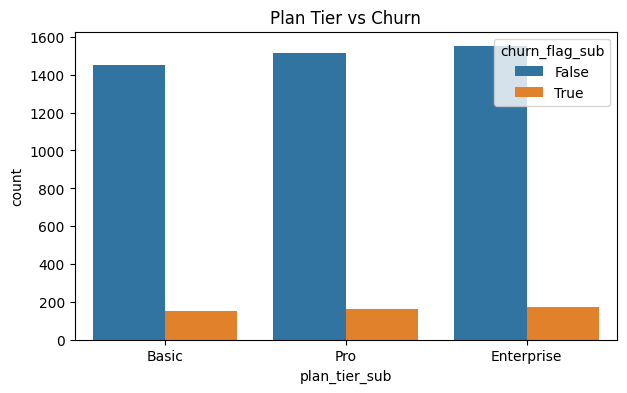

In [29]:
plt.figure(figsize=(7,4))
sns.countplot(data=df, x='plan_tier_sub', hue='churn_flag_sub')
plt.title('Plan Tier vs Churn')
plt.show()

**Billing frequency impact**

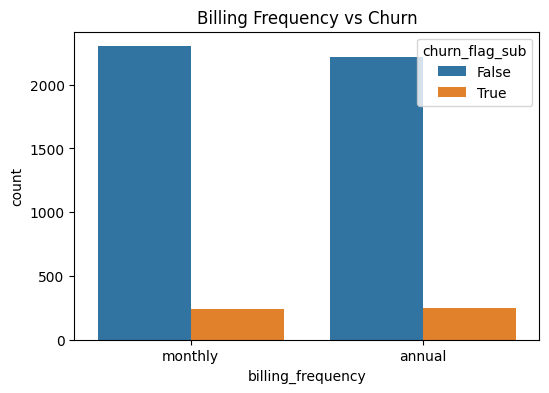

In [30]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='billing_frequency', hue='churn_flag_sub')
plt.title('Billing Frequency vs Churn')
plt.show()

**Auto renew impact**

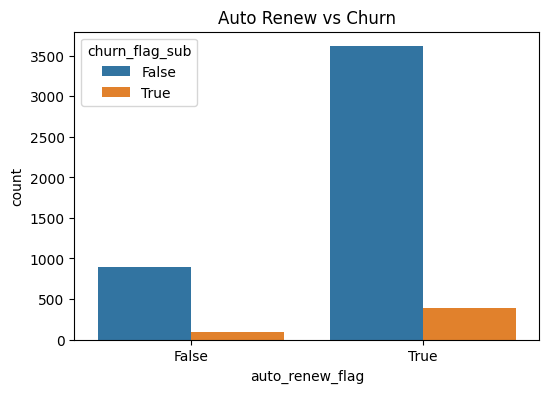

In [31]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='auto_renew_flag', hue='churn_flag_sub')
plt.title('Auto Renew vs Churn')
plt.show()

**Support risk vs revenue**

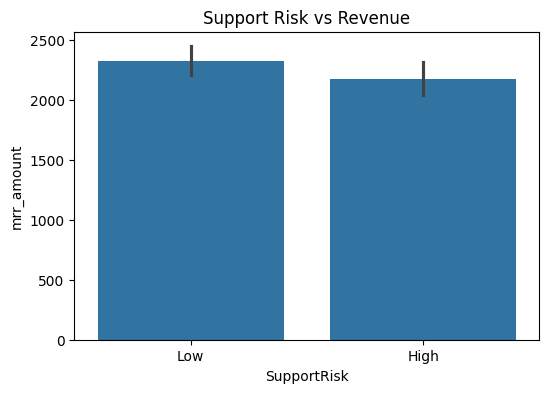

In [32]:
plt.figure(figsize=(6,4))
sns.barplot(data=df, x='SupportRisk', y='mrr_amount')
plt.title('Support Risk vs Revenue')
plt.show()

**Usage segment vs revenue**

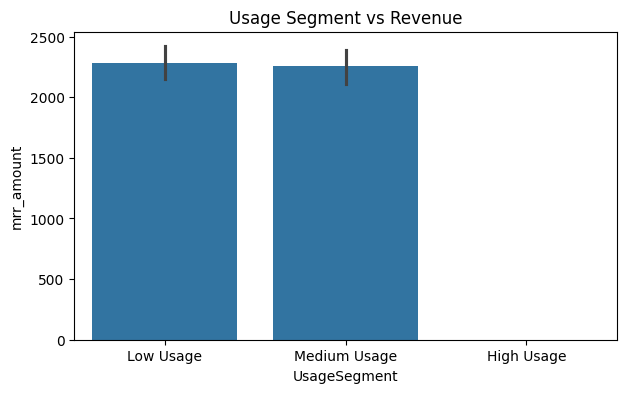

In [33]:
plt.figure(figsize=(7,4))
sns.barplot(data=df, x='UsageSegment', y='mrr_amount')
plt.title('Usage Segment vs Revenue')
plt.show()

**Industry distribution**

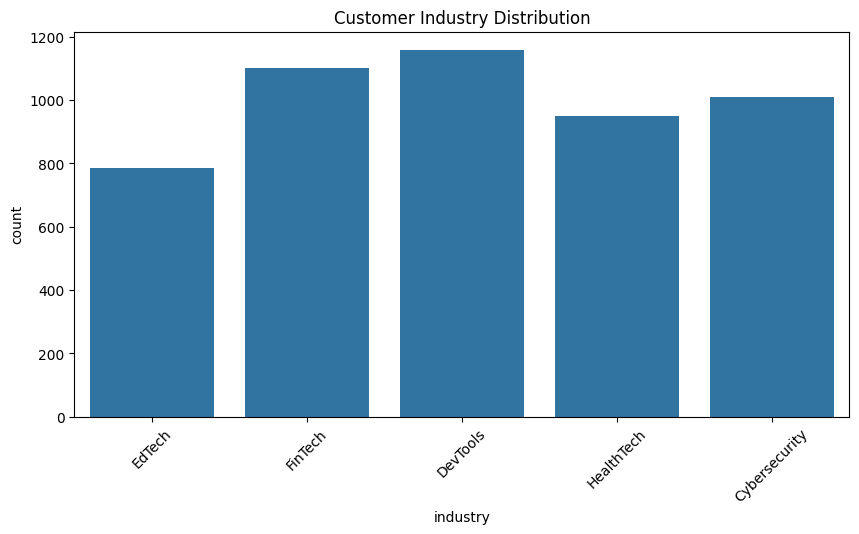

In [34]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='industry')
plt.xticks(rotation=45)
plt.title('Customer Industry Distribution')
plt.show()

**Country distribution**

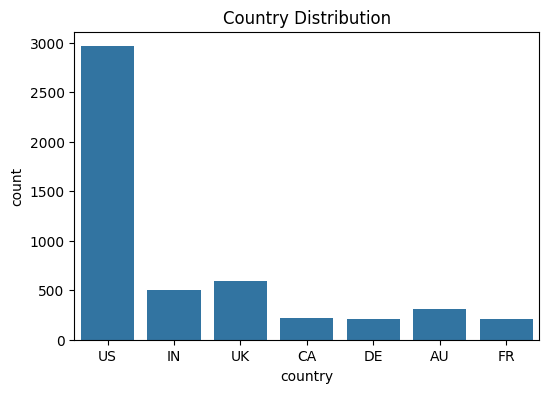

In [35]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='country')
plt.title('Country Distribution')
plt.show()

**Revenue by plan**

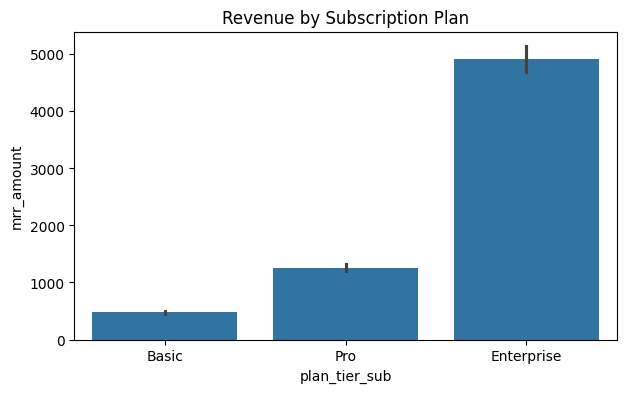

In [36]:
plt.figure(figsize=(7,4))
sns.barplot(data=df, x='plan_tier_sub', y='mrr_amount')
plt.title('Revenue by Subscription Plan')
plt.show()

**Satisfaction vs churn**

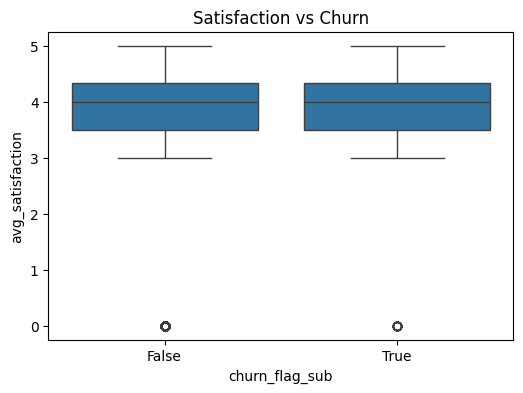

In [37]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='churn_flag_sub', y='avg_satisfaction')
plt.title('Satisfaction vs Churn')
plt.show()

**Correlation heatmap**

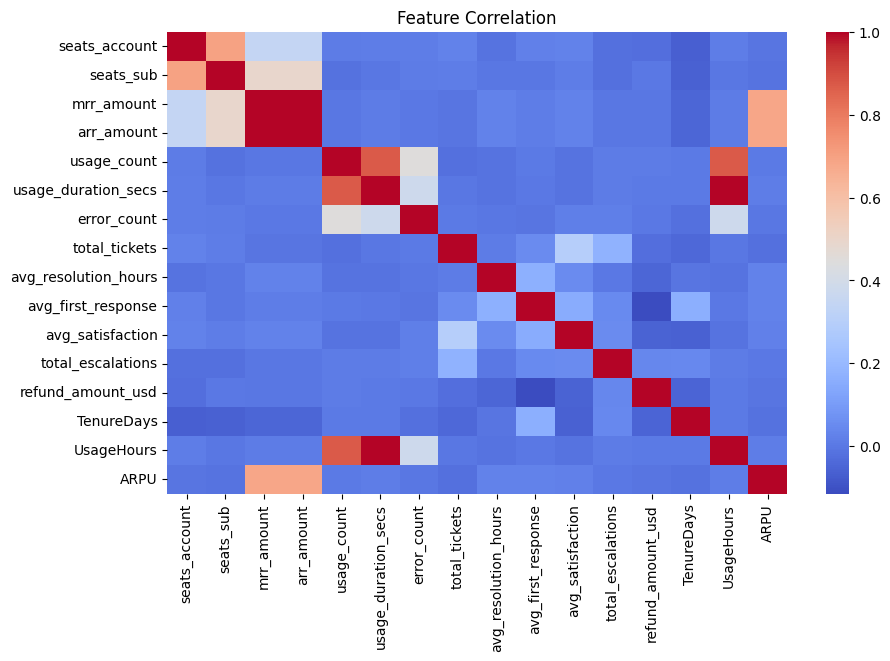

In [38]:
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=False, cmap='coolwarm')
plt.title('Feature Correlation')
plt.show()

**Save Cleaned Dataset**

In [39]:
df.to_csv('saas_retention_cleaned.csv', index=False)